In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 50)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [12]:
df = pd.read_csv("multi_touch_attribution_data.csv")

print("Dataset Loaded Successfully")
print("Shape:", df.shape)

display(df.head())

Dataset Loaded Successfully
Shape: (10000, 5)


,User ID,Timestamp,Channel,Campaign,Conversion
0,83281,2025-02-10 07:58:51,Email,New Product Launch,No
1,68071,2025-02-10 23:38:48,Search Ads,Winter Sale,No
2,90131,2025-02-11 10:41:07,Social Media,Brand Awareness,Yes
3,71026,2025-02-10 08:19:44,Direct Traffic,-,Yes
4,94486,2025-02-10 15:15:46,Email,Retargeting,Yes


In [20]:
#Overview of Dataset
print("Columns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Info:")
print(df.info())

Columns:
['user_id', 'timestamp', 'channel', 'campaign', 'conversion']

Data Types:
user_id                int64
timestamp     datetime64[ns]
channel               object
campaign              object
conversion            object
dtype: object

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     10000 non-null  int64         
 1   timestamp   10000 non-null  datetime64[ns]
 2   channel     10000 non-null  object        
 3   campaign    6869 non-null   object        
 4   conversion  10000 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 390.8+ KB
None


In [22]:
#Standardize Columns
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)

print(df.columns.tolist())

['user_id', 'timestamp', 'channel', 'campaign', 'conversion']


In [24]:
#Data Cleaning
df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    errors="coerce"
)

df["channel"] = (
    df["channel"]
      .astype(str)
      .str.strip()
)

df["campaign"] = (
    df["campaign"]
      .astype(str)
      .str.strip()
)

df["conversion"] = (
    df["conversion"]
      .astype(str)
      .str.strip()
      .str.lower()
)

df["campaign"] = df["campaign"].replace("-", np.nan)

display(df.head())

,user_id,timestamp,channel,campaign,conversion
0,83281,2025-02-10 07:58:51,Email,New Product Launch,no
1,68071,2025-02-10 23:38:48,Search Ads,Winter Sale,no
2,90131,2025-02-11 10:41:07,Social Media,Brand Awareness,yes
3,71026,2025-02-10 08:19:44,Direct Traffic,nan,yes
4,94486,2025-02-10 15:15:46,Email,Retargeting,yes


In [26]:
#Data Quality Checks
print("Null Values")
print(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

print("\nUnique Users")
print(df["user_id"].nunique())

Null Values
user_id       0
timestamp     0
channel       0
campaign      0
conversion    0
dtype: int64

Duplicate Rows
0

Unique Users
2847


In [28]:
#UTM Missing Analysis
utm_cols = [
    "utm_source",
    "utm_medium",
    "utm_campaign"
]

existing_utm = [
    col for col in utm_cols
    if col in df.columns
]

if existing_utm:

    missing_utm = (
        df[existing_utm]
        .isnull()
        .sum()
        .reset_index()
    )

    missing_utm.columns = [
        "utm_parameter",
        "missing_count"
    ]

    missing_utm["missing_pct"] = (
        missing_utm["missing_count"]
        / len(df)
        * 100
    )

    display(missing_utm)

else:
    print("No UTM columns available")

No UTM columns available


In [30]:
#Timezone Standardization
df["timestamp_utc"] = pd.to_datetime(
    df["timestamp"],
    utc=True,
    errors="coerce"
)

df["timestamp_ist"] = (
    df["timestamp_utc"]
    .dt.tz_convert("Asia/Kolkata")
)

display(
    df[
        [
            "timestamp_utc",
            "timestamp_ist"
        ]
    ].head()
)

,timestamp_utc,timestamp_ist
0,2025-02-10 07:58:51+00:00,2025-02-10 13:28:51+05:30
1,2025-02-10 23:38:48+00:00,2025-02-11 05:08:48+05:30
2,2025-02-11 10:41:07+00:00,2025-02-11 16:11:07+05:30
3,2025-02-10 08:19:44+00:00,2025-02-10 13:49:44+05:30
4,2025-02-10 15:15:46+00:00,2025-02-10 20:45:46+05:30


In [32]:
#Feature Engineering
df["date"] = df["timestamp"].dt.date
df["hour"] = df["timestamp"].dt.hour
df["day_name"] = df["timestamp"].dt.day_name()

df["conversion_flag"] = (
    df["conversion"]
    .map(
        {
            "yes": 1,
            "no": 0
        }
    )
)

display(df.head())

,user_id,timestamp,channel,campaign,conversion,timestamp_utc,timestamp_ist,date,hour,day_name,conversion_flag
0,83281,2025-02-10 07:58:51,Email,New Product Launch,no,2025-02-10 07:58:51+00:00,2025-02-10 13:28:51+05:30,2025-02-10,7,Monday,0
1,68071,2025-02-10 23:38:48,Search Ads,Winter Sale,no,2025-02-10 23:38:48+00:00,2025-02-11 05:08:48+05:30,2025-02-10,23,Monday,0
2,90131,2025-02-11 10:41:07,Social Media,Brand Awareness,yes,2025-02-11 10:41:07+00:00,2025-02-11 16:11:07+05:30,2025-02-11,10,Tuesday,1
3,71026,2025-02-10 08:19:44,Direct Traffic,nan,yes,2025-02-10 08:19:44+00:00,2025-02-10 13:49:44+05:30,2025-02-10,8,Monday,1
4,94486,2025-02-10 15:15:46,Email,Retargeting,yes,2025-02-10 15:15:46+00:00,2025-02-10 20:45:46+05:30,2025-02-10,15,Monday,1


In [34]:
#User Touchpoint Analysis
touchpoints_per_user = (
    df.groupby("user_id")
      .size()
      .reset_index(
          name="touchpoints"
      )
)

display(
    touchpoints_per_user.describe()
)

print(
    "Average Touchpoints:",
    round(
        touchpoints_per_user[
            "touchpoints"
        ].mean(),
        2
    )
)

,user_id,touchpoints
count,2847.000000,2847.000000
mean,54712.731647,3.512469
std,25728.417085,1.770702
min,10028.000000,1.000000
25%,31878.500000,2.000000
50%,55035.000000,3.000000
75%,77258.500000,5.000000
max,99995.000000,12.000000


Average Touchpoints: 3.51


In [36]:
#Customer Journey Creation
journey_df = (
    df.sort_values(
        [
            "user_id",
            "timestamp"
        ]
    )
    .copy()
)

journey_df["touchpoint_order"] = (
    journey_df.groupby(
        "user_id"
    )
    .cumcount()
    + 1
)

display(journey_df.head(20))

,user_id,timestamp,channel,campaign,conversion,timestamp_utc,timestamp_ist,date,hour,day_name,conversion_flag,touchpoint_order
8297,10028,2025-02-10 01:44:12,Search Ads,Discount Offer,yes,2025-02-10 01:44:12+00:00,2025-02-10 07:14:12+05:30,2025-02-10,1,Monday,1,1
3633,10028,2025-02-11 01:03:57,Display Ads,nan,yes,2025-02-11 01:03:57+00:00,2025-02-11 06:33:57+05:30,2025-02-11,1,Tuesday,1,2
9486,10045,2025-02-10 17:20:43,Search Ads,Discount Offer,no,2025-02-10 17:20:43+00:00,2025-02-10 22:50:43+05:30,2025-02-10,17,Monday,0,1
7663,10045,2025-02-11 18:44:15,Display Ads,New Product Launch,yes,2025-02-11 18:44:15+00:00,2025-02-12 00:14:15+05:30,2025-02-11,18,Tuesday,1,2
8643,10062,2025-02-10 15:42:42,Social Media,Brand Awareness,no,2025-02-10 15:42:42+00:00,2025-02-10 21:12:42+05:30,2025-02-10,15,Monday,0,1
7029,10062,2025-02-10 22:00:18,Direct Traffic,nan,no,2025-02-10 22:00:18+00:00,2025-02-11 03:30:18+05:30,2025-02-10,22,Monday,0,2
1967,10062,2025-02-11 21:10:27,Email,Brand Awareness,yes,2025-02-11 21:10:27+00:00,2025-02-12 02:40:27+05:30,2025-02-11,21,Tuesday,1,3
2080,10068,2025-02-10 07:07:39,Search Ads,nan,yes,2025-02-10 07:07:39+00:00,2025-02-10 12:37:39+05:30,2025-02-10,7,Monday,1,1
8457,10068,2025-02-11 08:05:04,Social Media,Retargeting,no,2025-02-11 08:05:04+00:00,2025-02-11 13:35:04+05:30,2025-02-11,8,Tuesday,0,2
9490,10068,2025-02-11 10:14:02,Social Media,Brand Awareness,yes,2025-02-11 10:14:02+00:00,2025-02-11 15:44:02+05:30,2025-02-11,10,Tuesday,1,3


In [38]:
#Customer Journey Paths
journey_paths = (
    journey_df
    .groupby("user_id")
    ["channel"]
    .apply(
        lambda x:
        " > ".join(x)
    )
    .reset_index()
)

journey_paths.columns = [
    "user_id",
    "journey_path"
]

display(journey_paths.head())

top_paths = (
    journey_paths[
        "journey_path"
    ]
    .value_counts()
    .head(10)
)

display(top_paths)

,user_id,journey_path
0,10028,Search Ads > Display Ads
1,10045,Search Ads > Display Ads
2,10062,Social Media > Direct Traffic > Email
3,10068,Search Ads > Social Media > Social Media > Sea...
4,10095,Display Ads > Email > Referral > Display Ads >...


journey_path
Search Ads                      65
Display Ads                     60
Direct Traffic                  58
Email                           54
Social Media                    54
Referral                        52
Referral > Social Media         26
Display Ads > Direct Traffic    24
Referral > Search Ads           23
Referral > Email                21
Name: count, dtype: int64

In [40]:
#Funnel Analysis
funnel_df = (
    df.groupby("channel")
      .agg(
          users=(
              "user_id",
              "nunique"
          ),
          conversions=(
              "conversion_flag",
              "sum"
          )
      )
      .reset_index()
)

funnel_df[
    "conversion_rate_pct"
] = (
    funnel_df["conversions"]
    /
    funnel_df["users"]
    * 100
)

display(
    funnel_df.sort_values(
        "conversion_rate_pct",
        ascending=False
    )
)

,channel,users,conversions,conversion_rate_pct
0,Direct Traffic,1287,853,66.278166
1,Display Ads,1254,828,66.028708
2,Email,1264,830,65.664557
3,Referral,1291,841,65.143300
5,Social Media,1285,820,63.813230
4,Search Ads,1259,772,61.318507


In [42]:
#Touchpoints vs Conversion
user_summary = (
    df.groupby("user_id")
      .agg(
          touchpoints=(
              "user_id",
              "size"
          ),
          converted=(
              "conversion_flag",
              "max"
          )
      )
      .reset_index()
)

display(user_summary.head())

,user_id,touchpoints,converted
0,10028,2,1
1,10045,2,1
2,10062,3,1
3,10068,5,1
4,10095,6,1


In [44]:
#First Touch Attribution
first_touch = (
    journey_df
    .groupby("user_id")
    .first()
    .reset_index()
)

first_touch_attr = (
    first_touch
    .groupby("channel")
    ["conversion_flag"]
    .sum()
    .reset_index()
)

display(
    first_touch_attr
    .sort_values(
        "conversion_flag",
        ascending=False
    )
)

,channel,conversion_flag
1,Display Ads,254
0,Direct Traffic,248
3,Referral,235
5,Social Media,234
2,Email,221
4,Search Ads,211


In [46]:
#Last Touch Attribution
last_touch = (
    journey_df
    .groupby("user_id")
    .last()
    .reset_index()
)

last_touch_attr = (
    last_touch
    .groupby("channel")
    ["conversion_flag"]
    .sum()
    .reset_index()
)

display(
    last_touch_attr
    .sort_values(
        "conversion_flag",
        ascending=False
    )
)

,channel,conversion_flag
3,Referral,250
1,Display Ads,238
0,Direct Traffic,236
2,Email,235
4,Search Ads,230
5,Social Media,221


In [48]:
#Linear Attribution
journey_df["journey_length"] = (
    journey_df
    .groupby("user_id")
    ["user_id"]
    .transform("count")
)

journey_df["linear_credit"] = (
    journey_df["conversion_flag"]
    /
    journey_df["journey_length"]
)

linear_attr = (
    journey_df
    .groupby("channel")
    ["linear_credit"]
    .sum()
    .reset_index()
)

display(
    linear_attr
    .sort_values(
        "linear_credit",
        ascending=False
    )
)

,channel,linear_credit
0,Direct Traffic,243.323990
1,Display Ads,242.759271
3,Referral,237.867893
5,Social Media,233.470310
2,Email,231.149242
4,Search Ads,222.683009


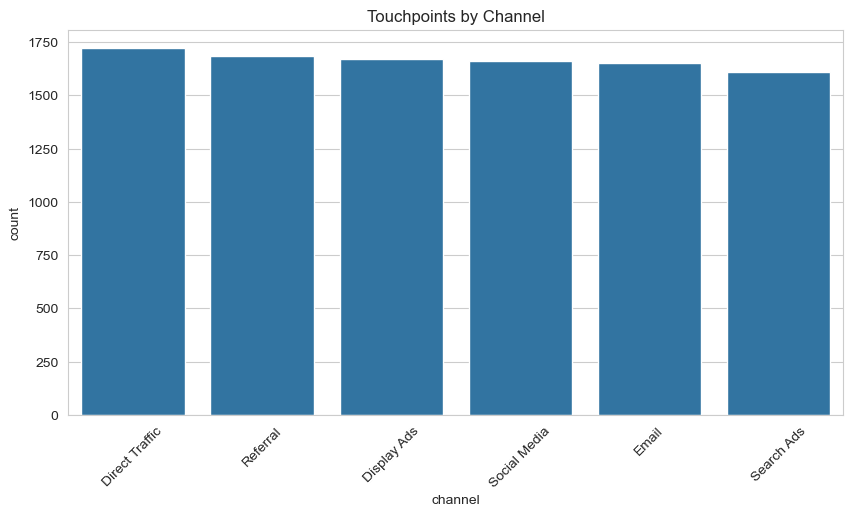

In [50]:
#Visualizations
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="channel",
    order=df[
        "channel"
    ]
    .value_counts()
    .index
)

plt.title(
    "Touchpoints by Channel"
)

plt.xticks(rotation=45)

plt.show()

In [54]:
#Attribution Ready Dataset
attribution_df = (
    journey_df[
        [
            "user_id",
            "timestamp",
            "channel",
            "campaign",
            "conversion_flag",
            "touchpoint_order"
        ]
    ]
)

display(
    attribution_df.head()
)

,user_id,timestamp,channel,campaign,conversion_flag,touchpoint_order
8297,10028,2025-02-10 01:44:12,Search Ads,Discount Offer,1,1
3633,10028,2025-02-11 01:03:57,Display Ads,nan,1,2
9486,10045,2025-02-10 17:20:43,Search Ads,Discount Offer,0,1
7663,10045,2025-02-11 18:44:15,Display Ads,New Product Launch,1,2
8643,10062,2025-02-10 15:42:42,Social Media,Brand Awareness,0,1


C:\Users\Dell\AppData\Local\Temp\ipykernel_1436\1683825342.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="channel", order=df["channel"].value_counts().index, palette="Set2")


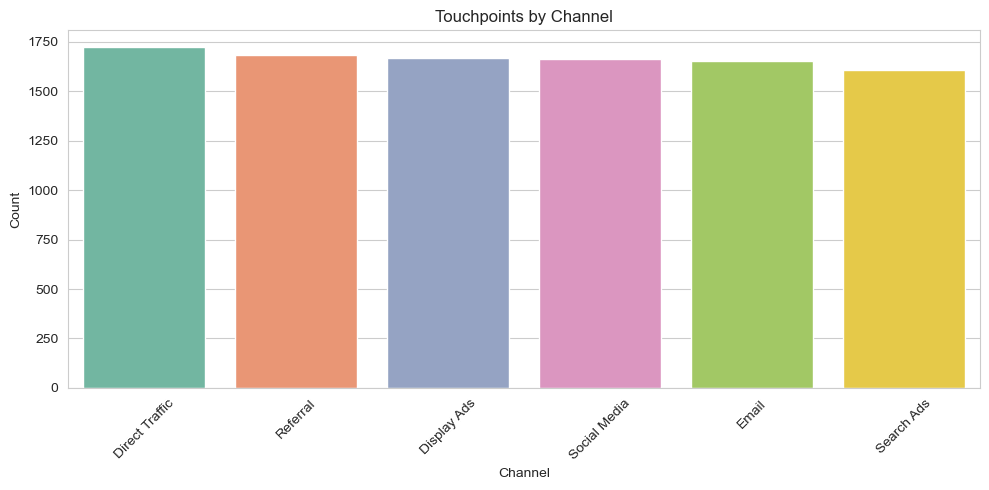

In [58]:
# Channel distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="channel", order=df["channel"].value_counts().index, palette="Set2")
plt.title("Touchpoints by Channel")
plt.xlabel("Channel")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\Dell\AppData\Local\Temp\ipykernel_1436\1267643115.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="campaign", order=df["campaign"].value_counts().index, palette="Set3")


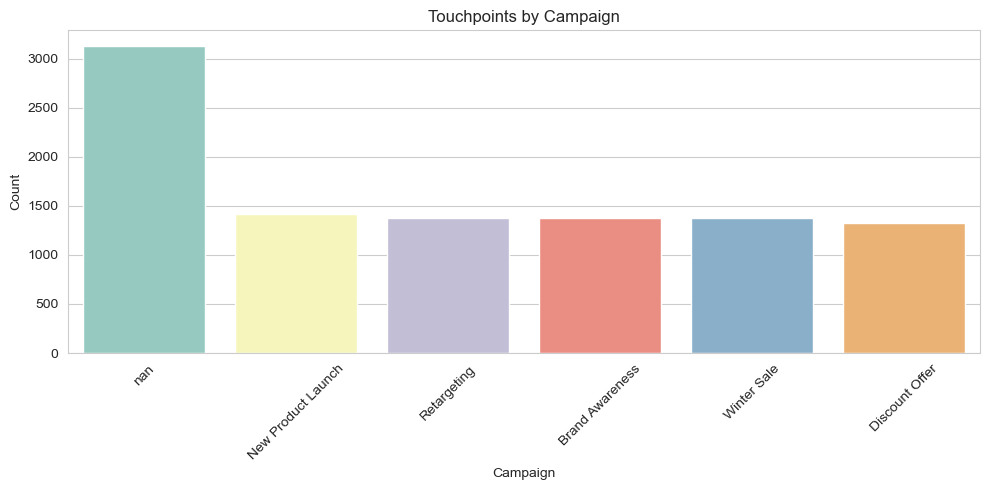

In [60]:
# Campaign distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="campaign", order=df["campaign"].value_counts().index, palette="Set3")
plt.title("Touchpoints by Campaign")
plt.xlabel("Campaign")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

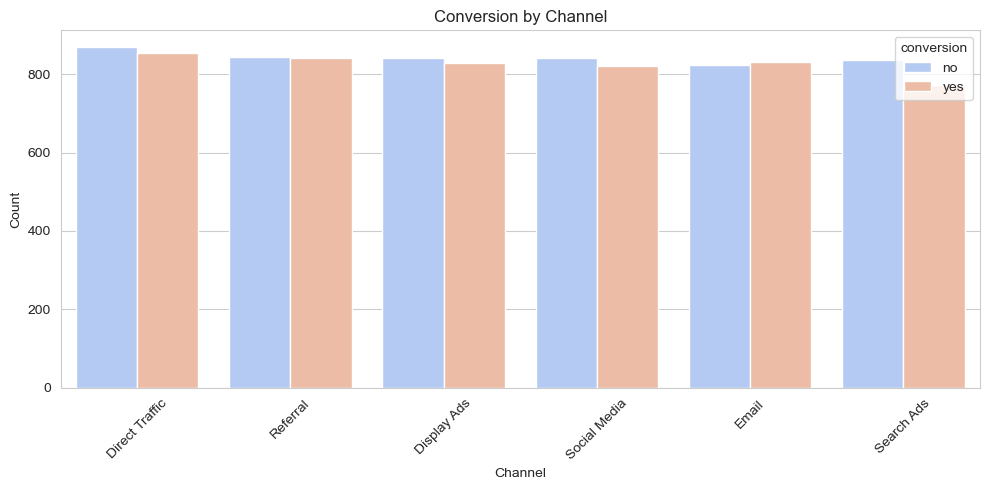

In [62]:
# Conversion by Channel
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="channel", hue="conversion", order=df["channel"].value_counts().index, palette="coolwarm")
plt.title("Conversion by Channel")
plt.xlabel("Channel")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

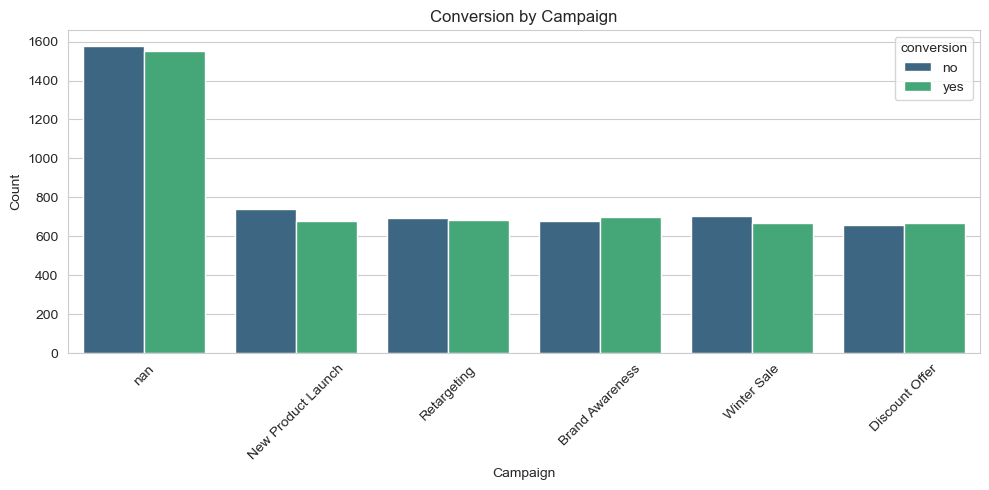

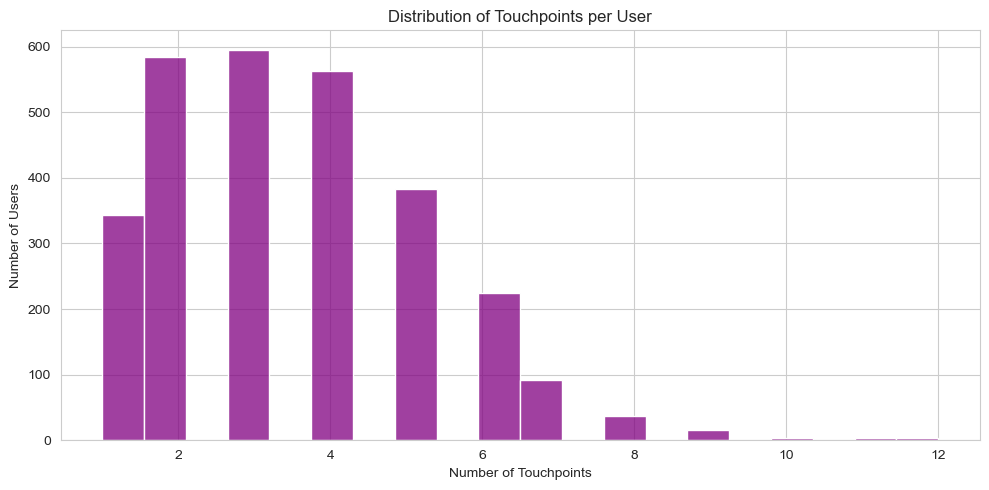

In [64]:
# Conversion by Campaign
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="campaign", hue="conversion", order=df["campaign"].value_counts().index, palette="viridis")
plt.title("Conversion by Campaign")
plt.xlabel("Campaign")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Chart 5: Touchpoints per user distribution
plt.figure(figsize=(10, 5))
sns.histplot(touchpoints_per_user["touchpoints"], bins=20, kde=False, color="purple")
plt.title("Distribution of Touchpoints per User")
plt.xlabel("Number of Touchpoints")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.show()


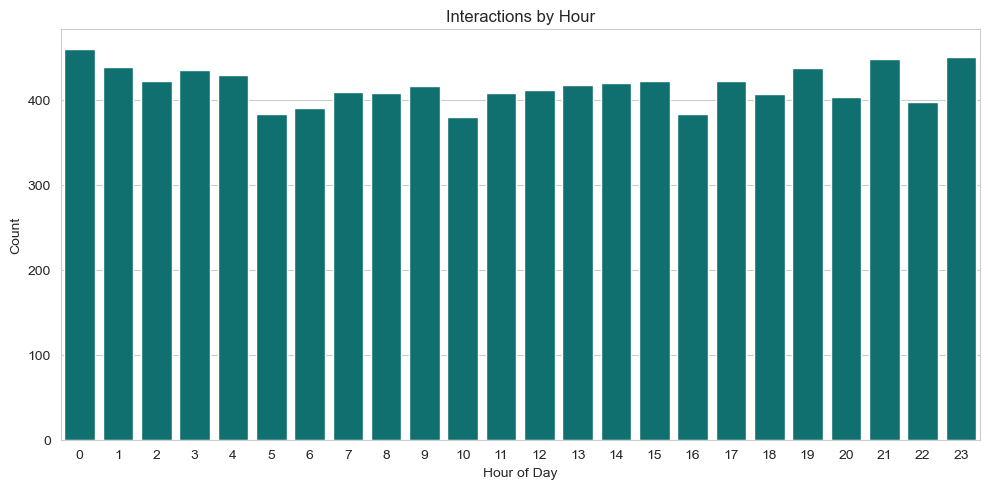

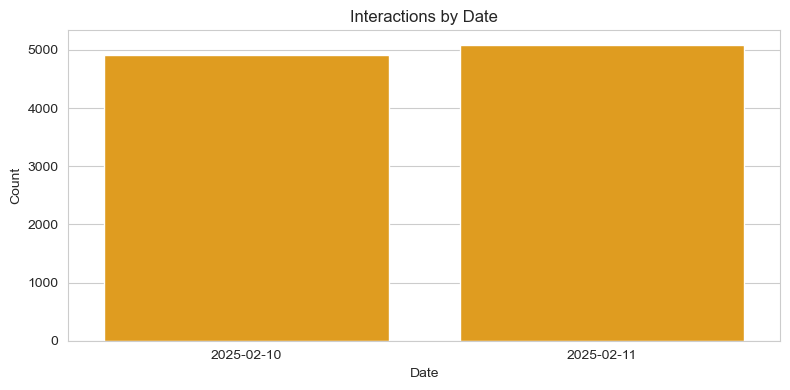

In [66]:
# Interactions by hour
hour_counts = df["hour"].value_counts().sort_index()
plt.figure(figsize=(10, 5))
sns.barplot(x=hour_counts.index, y=hour_counts.values, color="teal")
plt.title("Interactions by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Interactions by date
date_counts = df["date"].value_counts().sort_index()
plt.figure(figsize=(8, 4))
sns.barplot(x=date_counts.index.astype(str), y=date_counts.values, color="orange")
plt.title("Interactions by Date")
plt.xlabel("Date")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [76]:
# Converted users analysis

converted_users = (
    df[df["conversion"] == "yes"]["user_id"]
    .unique()
)

converted_df = (
    df[df["user_id"].isin(converted_users)]
    .copy()
)

converted_touchpoints = (
    converted_df
    .groupby("user_id")
    .size()
    .reset_index(
        name="touchpoints_before_or_with_conversion"
    )
)

print("Converted Users Count:")
print(len(converted_users))

display(converted_touchpoints.head())

Converted Users Count:
2381


,user_id,touchpoints_before_or_with_conversion
0,10028,2
1,10045,2
2,10062,3
3,10068,5
4,10095,6


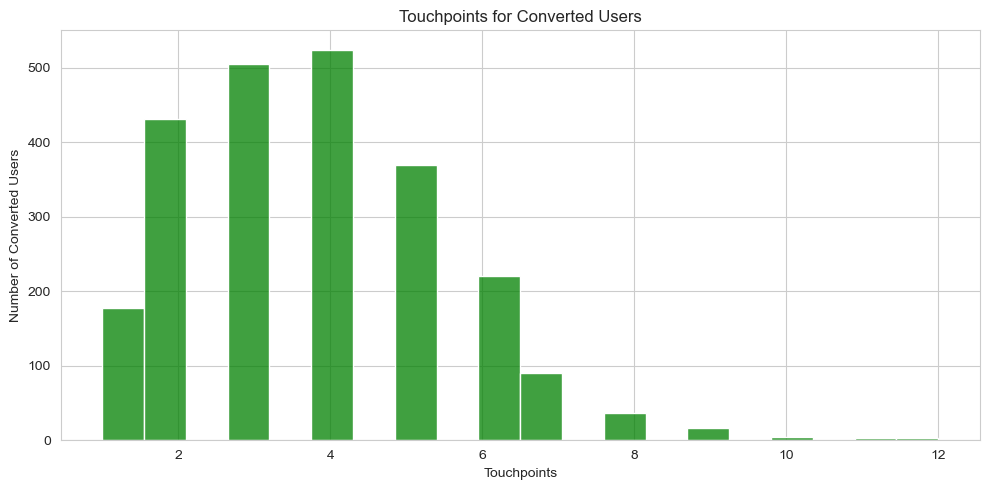

In [78]:
plt.figure(figsize=(10, 5))

sns.histplot(
    converted_touchpoints[
        "touchpoints_before_or_with_conversion"
    ],
    bins=20,
    kde=False,
    color="green"
)

plt.title(
    "Touchpoints for Converted Users"
)

plt.xlabel("Touchpoints")
plt.ylabel("Number of Converted Users")

plt.tight_layout()
plt.show()

In [72]:

# Top channels by total records
top_channels = df["channel"].value_counts().reset_index()
top_channels.columns = ["channel", "count"]

# Top campaigns by total records
top_campaigns = df["campaign"].value_counts(dropna=False).reset_index()
top_campaigns.columns = ["campaign", "count"]

# Conversion rate by channel
channel_conv_rate = df.groupby("channel")["conversion_flag"].mean().reset_index()
channel_conv_rate["conversion_rate_pct"] = channel_conv_rate["conversion_flag"] * 100
channel_conv_rate = channel_conv_rate.sort_values(by="conversion_rate_pct", ascending=False)

# Conversion rate by campaign
campaign_conv_rate = df.groupby("campaign")["conversion_flag"].mean().reset_index()
campaign_conv_rate["conversion_rate_pct"] = campaign_conv_rate["conversion_flag"] * 100
campaign_conv_rate = campaign_conv_rate.sort_values(by="conversion_rate_pct", ascending=False)

print("\nTop channels:")
display(top_channels)

print("\nTop campaigns:")
display(top_campaigns)
print("\nConversion rate by channel:")
display(channel_conv_rate.round(2))

print("\nConversion rate by campaign:")
display(campaign_conv_rate.round(2))




Top channels:


,channel,count
0,Direct Traffic,1721
1,Referral,1685
2,Display Ads,1669
3,Social Media,1662
4,Email,1654
5,Search Ads,1609



Top campaigns:


,campaign,count
0,nan,3131
1,New Product Launch,1416
2,Retargeting,1379
3,Brand Awareness,1378
4,Winter Sale,1372
5,Discount Offer,1324



Conversion rate by channel:


,channel,conversion_flag,conversion_rate_pct
2,Email,0.50,50.18
3,Referral,0.50,49.91
1,Display Ads,0.50,49.61
0,Direct Traffic,0.50,49.56
5,Social Media,0.49,49.34
4,Search Ads,0.48,47.98



Conversion rate by campaign:


,campaign,conversion_flag,conversion_rate_pct
0,Brand Awareness,0.51,50.65
1,Discount Offer,0.50,50.45
5,nan,0.50,49.57
3,Retargeting,0.50,49.53
4,Winter Sale,0.49,48.62
2,New Product Launch,0.48,47.74


In [74]:

#  Journey sequencing preview

# Sort journey data by user and timestamp
journey_df = df.sort_values(by=["user_id", "timestamp"]).copy()

# Add sequence number
journey_df["touchpoint_order"] = journey_df.groupby("user_id").cumcount() + 1

print("\nUser journey preview:")
display(journey_df.head(20))


#  First-touch and last-touch preview for EDA understanding

first_touch = journey_df.groupby("user_id").first().reset_index()
last_touch = journey_df.groupby("user_id").last().reset_index()

print("\nFirst touch sample:")
display(first_touch.head())

print("\nLast touch sample:")
display(last_touch.head())


User journey preview:


,user_id,timestamp,channel,campaign,conversion,timestamp_utc,timestamp_ist,date,hour,day_name,conversion_flag,touchpoint_order
8297,10028,2025-02-10 01:44:12,Search Ads,Discount Offer,yes,2025-02-10 01:44:12+00:00,2025-02-10 07:14:12+05:30,2025-02-10,1,Monday,1,1
3633,10028,2025-02-11 01:03:57,Display Ads,nan,yes,2025-02-11 01:03:57+00:00,2025-02-11 06:33:57+05:30,2025-02-11,1,Tuesday,1,2
9486,10045,2025-02-10 17:20:43,Search Ads,Discount Offer,no,2025-02-10 17:20:43+00:00,2025-02-10 22:50:43+05:30,2025-02-10,17,Monday,0,1
7663,10045,2025-02-11 18:44:15,Display Ads,New Product Launch,yes,2025-02-11 18:44:15+00:00,2025-02-12 00:14:15+05:30,2025-02-11,18,Tuesday,1,2
8643,10062,2025-02-10 15:42:42,Social Media,Brand Awareness,no,2025-02-10 15:42:42+00:00,2025-02-10 21:12:42+05:30,2025-02-10,15,Monday,0,1
7029,10062,2025-02-10 22:00:18,Direct Traffic,nan,no,2025-02-10 22:00:18+00:00,2025-02-11 03:30:18+05:30,2025-02-10,22,Monday,0,2
1967,10062,2025-02-11 21:10:27,Email,Brand Awareness,yes,2025-02-11 21:10:27+00:00,2025-02-12 02:40:27+05:30,2025-02-11,21,Tuesday,1,3
2080,10068,2025-02-10 07:07:39,Search Ads,nan,yes,2025-02-10 07:07:39+00:00,2025-02-10 12:37:39+05:30,2025-02-10,7,Monday,1,1
8457,10068,2025-02-11 08:05:04,Social Media,Retargeting,no,2025-02-11 08:05:04+00:00,2025-02-11 13:35:04+05:30,2025-02-11,8,Tuesday,0,2
9490,10068,2025-02-11 10:14:02,Social Media,Brand Awareness,yes,2025-02-11 10:14:02+00:00,2025-02-11 15:44:02+05:30,2025-02-11,10,Tuesday,1,3



First touch sample:


,user_id,timestamp,channel,campaign,conversion,timestamp_utc,timestamp_ist,date,hour,day_name,conversion_flag,touchpoint_order
0,10028,2025-02-10 01:44:12,Search Ads,Discount Offer,yes,2025-02-10 01:44:12+00:00,2025-02-10 07:14:12+05:30,2025-02-10,1,Monday,1,1
1,10045,2025-02-10 17:20:43,Search Ads,Discount Offer,no,2025-02-10 17:20:43+00:00,2025-02-10 22:50:43+05:30,2025-02-10,17,Monday,0,1
2,10062,2025-02-10 15:42:42,Social Media,Brand Awareness,no,2025-02-10 15:42:42+00:00,2025-02-10 21:12:42+05:30,2025-02-10,15,Monday,0,1
3,10068,2025-02-10 07:07:39,Search Ads,nan,yes,2025-02-10 07:07:39+00:00,2025-02-10 12:37:39+05:30,2025-02-10,7,Monday,1,1
4,10095,2025-02-10 07:07:27,Display Ads,Retargeting,yes,2025-02-10 07:07:27+00:00,2025-02-10 12:37:27+05:30,2025-02-10,7,Monday,1,1



Last touch sample:


,user_id,timestamp,channel,campaign,conversion,timestamp_utc,timestamp_ist,date,hour,day_name,conversion_flag,touchpoint_order
0,10028,2025-02-11 01:03:57,Display Ads,nan,yes,2025-02-11 01:03:57+00:00,2025-02-11 06:33:57+05:30,2025-02-11,1,Tuesday,1,2
1,10045,2025-02-11 18:44:15,Display Ads,New Product Launch,yes,2025-02-11 18:44:15+00:00,2025-02-12 00:14:15+05:30,2025-02-11,18,Tuesday,1,2
2,10062,2025-02-11 21:10:27,Email,Brand Awareness,yes,2025-02-11 21:10:27+00:00,2025-02-12 02:40:27+05:30,2025-02-11,21,Tuesday,1,3
3,10068,2025-02-11 23:05:58,Social Media,Winter Sale,no,2025-02-11 23:05:58+00:00,2025-02-12 04:35:58+05:30,2025-02-11,23,Tuesday,0,5
4,10095,2025-02-11 23:24:48,Referral,nan,yes,2025-02-11 23:24:48+00:00,2025-02-12 04:54:48+05:30,2025-02-11,23,Tuesday,1,6


In [80]:
import os
print(os.getcwd())

C:\Users\Dell\Internship
